<a href="https://colab.research.google.com/github/theqxmlkushal/21_Days_of_LLM_coding-/blob/main/next_session_difficulty_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install scikit-learn xgboost

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
df = pd.read_csv("/content/training_data_by claude.csv")

In [ ]:
# SHAPE OF DATA
print(df.shape)
print("\n")

#LET'S SEE HOW OUR DATA LOOKS
print(df.sample(5))
print("\n")

(8000, 10)


      accuracy  avg_time_per_question  first_attempt_correct  \
1116      39.2                   64.3                   33.0   
6269      89.9                   21.1                   87.1   
1813      40.2                   55.1                   36.6   
2899      72.6                   39.5                   51.0   
1851      84.9                   31.5                   83.9   

      current_difficulty  sessions_completed  score_trend  mastery_level  \
1116                   1                   5        -15.8          0.362   
6269                   3                   9         14.6          0.897   
1813                   1                   1        -17.6          0.317   
2899                   1                  24          0.1          0.609   
1851                   2                  13         13.0          0.843   

      is_new_topic  next_difficulty  question_count  
1116             0                1               8  
6269             0                3  

In [ ]:
#NOW CHECKING FOR NULL VALUES
print(df.isnull().sum())
print("\n")

accuracy                 0
avg_time_per_question    0
first_attempt_correct    0
current_difficulty       0
sessions_completed       0
score_trend              0
mastery_level            0
is_new_topic             0
next_difficulty          0
question_count           0
dtype: int64




In [ ]:
#LET'S SEE DATA-TYPE OF ALL FEATURES
print(df.info())
print("\n")

# #STATISTICS OF ALL FEATURES
# print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   accuracy               8000 non-null   float64
 1   avg_time_per_question  8000 non-null   float64
 2   first_attempt_correct  8000 non-null   float64
 3   current_difficulty     8000 non-null   int64  
 4   sessions_completed     8000 non-null   int64  
 5   score_trend            8000 non-null   float64
 6   mastery_level          8000 non-null   float64
 7   is_new_topic           8000 non-null   int64  
 8   next_difficulty        8000 non-null   int64  
 9   question_count         8000 non-null   int64  
dtypes: float64(5), int64(5)
memory usage: 625.1 KB
None




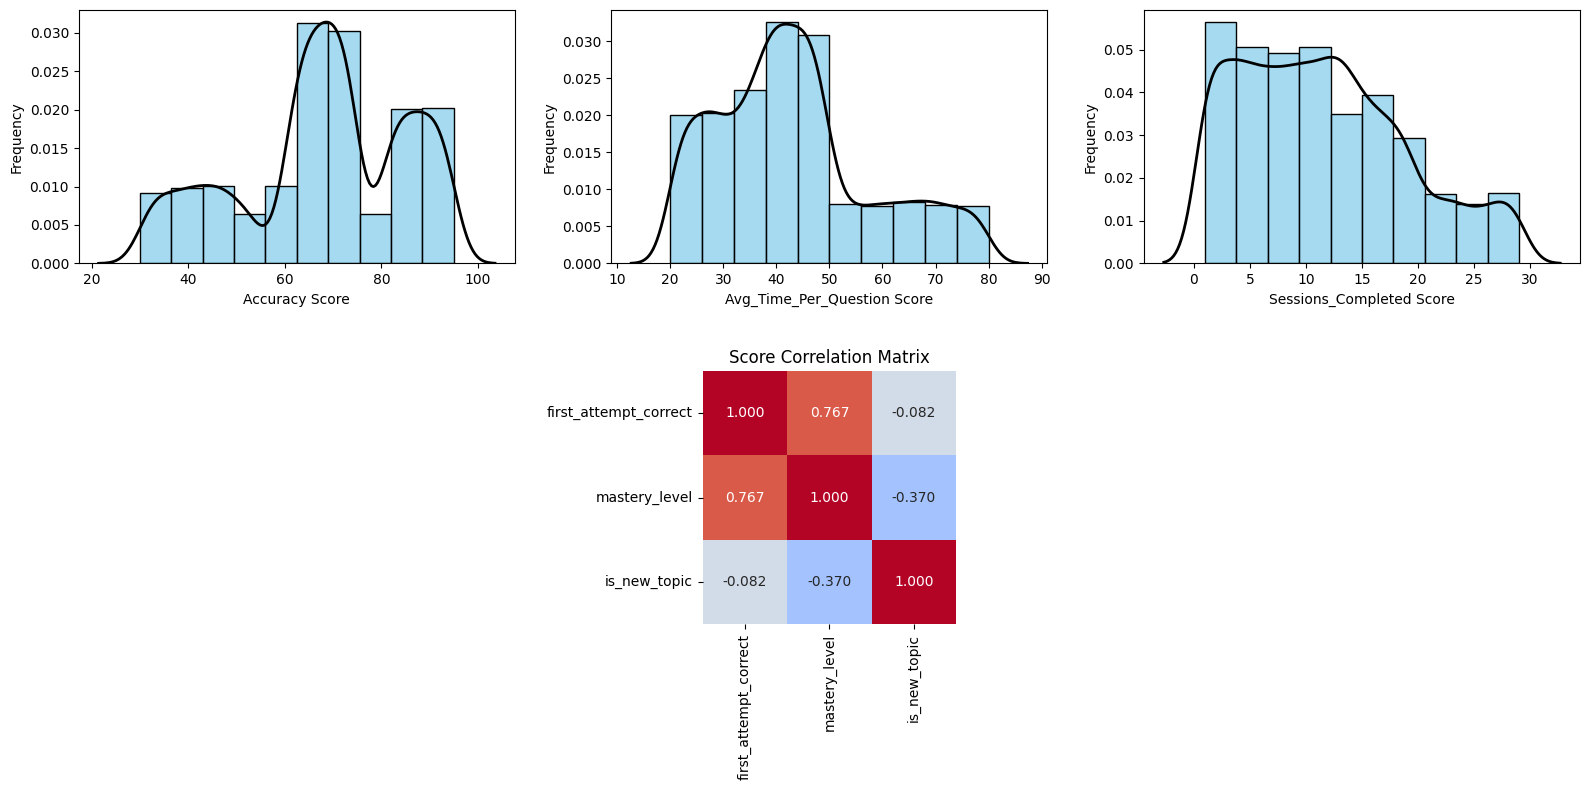

In [ ]:
numerical_cols = ['accuracy', 'avg_time_per_question', 'sessions_completed']
plt.figure(figsize=(16, 8))

for i, column in enumerate(numerical_cols):
    plt.subplot(2, 3, i+1)
    sns.histplot(df[column], bins=10, color='skyblue', stat='density', edgecolor='black')
    # KDE line => black
    sns.kdeplot(df[column], color='black', linewidth=2)
    plt.xlabel(f'{column.title()} Score')
    plt.ylabel('Frequency')


#Correlation HeatMap
plt.subplot(2, 3, (4, 6))
correlation = df[['first_attempt_correct', 'mastery_level', 'is_new_topic']].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, square=True, fmt='.3f',cbar = False)
plt.title('Score Correlation Matrix')


plt.tight_layout(h_pad=3, w_pad=2)
plt.show()

In [ ]:
numerical_cols = ['accuracy', 'avg_time_per_question', 'sessions_completed']
i = 0
plt.figure(figsize=(12, 4))
for i, nums_col in enumerate(numerical_cols):
    plt.subplot(1, 3, i+1)
    sns.boxplot(x=df[nums_col],color='steelblue',fliersize=8,linewidth=2,whis=1.5)
    plt.title(f'{nums_col.title()}')
    plt.xlabel(nums_col.title())
plt.tight_layout()
plt.show()

print("\n")
#CHECKING FOR THE DISTRIBUTION TO APPLY PROPER METHOD FOR OUTLIER REMOVAL
for nums_col in numerical_cols:
    skewness = df[nums_col].skew()
    print(f'{nums_col}: {skewness:.3f}')

print("\n")

#THE ACTUAL OUTLIERS
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    outliers = df[(df[col] > upper) | (df[col] < lower)][col].values
    print(f'{col} outliers: {outliers}')
    df[col] = np.where(df[col] < lower, lower, np.where(df[col] > upper, upper, df[col]))

plt.figure(figsize=(12, 4))
for i, nums_col in enumerate(numerical_cols):
    plt.subplot(1, 3, i+1)
    sns.boxplot(x=df[nums_col],color='steelblue',fliersize=8,linewidth=2,whis=1.5)
    plt.title(f'{nums_col.title()}')
    plt.xlabel(nums_col.title())
plt.tight_layout()
plt.show()

In [ ]:
feature_cols = df.drop(columns=['next_difficulty', 'question_count'])
X_train = feature_cols
y_train = df['next_difficulty']

In [ ]:
X_train_split, X_test, y_train_split, y_test = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

print(f"X_train_split shape: {X_train_split.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train_split shape: {y_train_split.shape}")
print(f"y_test shape: {y_test.shape}")

X_train_split shape: (6400, 8)
X_test shape: (1600, 8)
y_train_split shape: (6400,)
y_test shape: (1600,)


In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, RandomForestClassifier
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.model_selection import GridSearchCV
import xgboost as xgb
from xgboost import XGBClassifier

print("Required models and GridSearchCV imported successfully.")

Required models and GridSearchCV imported successfully.


In [ ]:
models_tuned = {
    'LogisticRegression': {
        'estimator': LogisticRegression(random_state=42, solver='liblinear'),
        'param_grid': {
            'C': [0.1, 1.0, 10.0],
            'penalty': ['l1', 'l2']
        }
    },
    'RandomForestClassifier': {
        'estimator': RandomForestClassifier(random_state=42),
        'param_grid': {
            'n_estimators': [50, 100, 150],
            'max_depth': [None, 10, 20]
        }
    },
    'XGBoostClassifier': {
        'estimator': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss'),
        'param_grid': {
            'n_estimators': [50, 100, 150],
            'learning_rate': [0.01, 0.1, 0.2],
            'max_depth': [3, 5, 7]
        }
    }
}

print("Classification models_tuned dictionary defined with parameter grids.")

Classification models_tuned dictionary defined with parameter grids.


In [ ]:
y_train_split_adjusted = y_train_split - 1
y_test_adjusted = y_test - 1

print(f"Adjusted y_train_split unique values: {np.unique(y_train_split_adjusted)}")
print(f"Adjusted y_test unique values: {np.unique(y_test_adjusted)}")

Adjusted y_train_split unique values: [0 1 2]
Adjusted y_test unique values: [0 1 2]


In [ ]:
for model_name, model_info in models_tuned.items():
    if model_info['param_grid']:
        estimator = model_info['estimator']
        param_grid = model_info['param_grid']

        print(f"Tuning {model_name}...")
        grid_search = GridSearchCV(
            estimator=estimator,
            param_grid=param_grid,
            cv=5,
            scoring='accuracy', # Changed to accuracy for classification
            n_jobs=-1,
            verbose=1
        )
        # Use adjusted target variable for fitting
        grid_search.fit(X_train_split, y_train_split_adjusted if model_name == 'XGBoostClassifier' else y_train_split)

        models_tuned[model_name]['estimator'] = grid_search.best_estimator_
        models_tuned[model_name]['best_params'] = grid_search.best_params_
        models_tuned[model_name]['best_score'] = grid_search.best_score_
        print(f"Finished tuning {model_name}. Best parameters: {grid_search.best_params_}")
    else:
        print(f"Skipping tuning for {model_name} as no param_grid is defined.")

print("\nUpdated models_tuned dictionary after hyperparameter tuning:")
for model_name, model_info in models_tuned.items():
    print(f"Model: {model_name}")
    print(f"  Estimator: {model_info['estimator']}")
    if 'best_params' in model_info:
        print(f"  Best Parameters: {model_info['best_params']}")
        print(f"  Best Score (accuracy): {model_info['best_score']}")
    print("\n")

Tuning LogisticRegression...
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Finished tuning LogisticRegression. Best parameters: {'C': 10.0, 'penalty': 'l1'}
Tuning RandomForestClassifier...
Fitting 5 folds for each of 9 candidates, totalling 45 fits
Finished tuning RandomForestClassifier. Best parameters: {'max_depth': None, 'n_estimators': 150}
Tuning XGBoostClassifier...
Fitting 5 folds for each of 27 candidates, totalling 135 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:08:34] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Finished tuning XGBoostClassifier. Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 150}

Updated models_tuned dictionary after hyperparameter tuning:
Model: LogisticRegression
  Estimator: LogisticRegression(C=10.0, penalty='l1', random_state=42, solver='liblinear')
  Best Parameters: {'C': 10.0, 'penalty': 'l1'}
  Best Score (accuracy): 0.9990625


Model: RandomForestClassifier
  Estimator: RandomForestClassifier(n_estimators=150, random_state=42)
  Best Parameters: {'max_depth': None, 'n_estimators': 150}
  Best Score (accuracy): 0.9989062499999999


Model: XGBoostClassifier
  Estimator: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type

In [ ]:
y_train_split_adjusted = y_train_split - 1
y_test_adjusted = y_test - 1

print(f"Adjusted y_train_split unique values: {np.unique(y_train_split_adjusted)}")
print(f"Adjusted y_test unique values: {np.unique(y_test_adjusted)}")

Adjusted y_train_split unique values: [0 1 2]
Adjusted y_test unique values: [0 1 2]


In [ ]:
y_train_split_adjusted = y_train_split - 1
y_test_adjusted = y_test - 1

print(f"Adjusted y_train_split unique values: {np.unique(y_train_split_adjusted)}")
print(f"Adjusted y_test unique values: {np.unique(y_test_adjusted)}")

Adjusted y_train_split unique values: [0 1 2]
Adjusted y_test unique values: [0 1 2]


In [ ]:
for model_name, model_info in models_tuned.items():
    if model_info['param_grid']:
        estimator = model_info['estimator']
        param_grid = model_info['param_grid']

        print(f"Tuning {model_name}...")
        grid_search = GridSearchCV(
            estimator=estimator,
            param_grid=param_grid,
            cv=5,
            scoring='accuracy', # Changed to accuracy for classification
            n_jobs=-1,
            verbose=1
        )
        # Use adjusted target variable for fitting
        if model_name == 'XGBoostClassifier':
            grid_search.fit(X_train_split, y_train_split_adjusted)
        else:
            grid_search.fit(X_train_split, y_train_split)

        models_tuned[model_name]['estimator'] = grid_search.best_estimator_
        models_tuned[model_name]['best_params'] = grid_search.best_params_
        models_tuned[model_name]['best_score'] = grid_search.best_score_
        print(f"Finished tuning {model_name}. Best parameters: {grid_search.best_params_}")
    else:
        print(f"Skipping tuning for {model_name} as no param_grid is defined.")

print("\nUpdated models_tuned dictionary after hyperparameter tuning:")
for model_name, model_info in models_tuned.items():
    print(f"Model: {model_name}")
    print(f"  Estimator: {model_info['estimator']}")
    if 'best_params' in model_info:
        print(f"  Best Parameters: {model_info['best_params']}")
        print(f"  Best Score (accuracy): {model_info['best_score']}")
    print("\n")

Tuning LogisticRegression...
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Finished tuning LogisticRegression. Best parameters: {'C': 10.0, 'penalty': 'l1'}
Tuning RandomForestClassifier...
Fitting 5 folds for each of 9 candidates, totalling 45 fits
Finished tuning RandomForestClassifier. Best parameters: {'max_depth': None, 'n_estimators': 150}
Tuning XGBoostClassifier...
Fitting 5 folds for each of 27 candidates, totalling 135 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:09:33] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Finished tuning XGBoostClassifier. Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 150}

Updated models_tuned dictionary after hyperparameter tuning:
Model: LogisticRegression
  Estimator: LogisticRegression(C=10.0, penalty='l1', random_state=42, solver='liblinear')
  Best Parameters: {'C': 10.0, 'penalty': 'l1'}
  Best Score (accuracy): 0.9990625


Model: RandomForestClassifier
  Estimator: RandomForestClassifier(n_estimators=150, random_state=42)
  Best Parameters: {'max_depth': None, 'n_estimators': 150}
  Best Score (accuracy): 0.9989062499999999


Model: XGBoostClassifier
  Estimator: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type

### Predict Next Difficulty

Use the input fields below to provide values for the features and get a prediction for the `next_difficulty` using the best performing model (XGBoostClassifier).

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

print("Required evaluation metrics imported successfully.")

Required evaluation metrics imported successfully.


In [ ]:
model_performance = {}

for model_name, model_info in models_tuned.items():
    estimator = model_info['estimator']

    # Make predictions on the test set
    y_pred = estimator.predict(X_test)

    # Calculate evaluation metrics
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    # Store the performance metrics
    model_performance[model_name] = {
        'R-squared': r2,
        'MSE': mse,
        'MAE': mae
    }

print("Model Evaluation Results:")
for model_name, metrics in model_performance.items():
    print(f"\n{model_name}:")
    for metric_name, value in metrics.items():
        print(f"  {metric_name}: {value:.6f}")

Model Evaluation Results:

LogisticRegression:
  R-squared: 0.999031
  MSE: 0.000625
  MAE: 0.000625

RandomForestClassifier:
  R-squared: 1.000000
  MSE: 0.000000
  MAE: 0.000000

XGBoostClassifier:
  R-squared: -0.555720
  MSE: 1.003750
  MAE: 1.001250


In [ ]:
model_performance = {}

for model_name, model_info in models_tuned.items():
    estimator = model_info['estimator']

    # If the model was not tuned (e.g., LinearRegression, RidgeRegression),
    # it needs to be fitted manually to the training data before prediction.
    if not model_info['param_grid']:
        print(f"Fitting {model_name} as it was not tuned by GridSearchCV...")
        estimator.fit(X_train_split, y_train_split)

    # Make predictions on the test set
    y_pred = estimator.predict(X_test)

    # Calculate evaluation metrics
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    # Store the performance metrics
    model_performance[model_name] = {
        'R-squared': r2,
        'MSE': mse,
        'MAE': mae
    }

print("Model Evaluation Results:")
for model_name, metrics in model_performance.items():
    print(f"\n{model_name}:")
    for metric_name, value in metrics.items():
        print(f"  {metric_name}: {value:.6f}")

Model Evaluation Results:

LogisticRegression:
  R-squared: 0.999031
  MSE: 0.000625
  MAE: 0.000625

RandomForestClassifier:
  R-squared: 1.000000
  MSE: 0.000000
  MAE: 0.000000

XGBoostClassifier:
  R-squared: -0.555720
  MSE: 1.003750
  MAE: 1.001250


In [ ]:
best_r2_score = -float('inf')
best_r2_model = ''
best_mse_score = float('inf')
best_mse_model = ''
best_mae_score = float('inf')
best_mae_model = ''

for model_name, metrics in model_performance.items():
    if metrics['R-squared'] > best_r2_score:
        best_r2_score = metrics['R-squared']
        best_r2_model = model_name

    if metrics['MSE'] < best_mse_score:
        best_mse_score = metrics['MSE']
        best_mse_model = model_name

    if metrics['MAE'] < best_mae_score:
        best_mae_score = metrics['MAE']
        best_mae_model = model_name

print("\n--- Overall Model Performance ---")
for model_name, metrics in model_performance.items():
    print(f"\n{model_name}:")
    for metric_name, value in metrics.items():
        print(f"  {metric_name}: {value:.6f}")

print("\n--- Best Performing Models ---")
print(f"Best Model by R-squared: {best_r2_model} (R-squared: {best_r2_score:.6f})")
print(f"Best Model by MSE: {best_mse_model} (MSE: {best_mse_score:.6f})")
print(f"Best Model by MAE: {best_mae_model} (MAE: {best_mae_score:.6f})")



--- Overall Model Performance ---

LogisticRegression:
  R-squared: 0.999031
  MSE: 0.000625
  MAE: 0.000625

RandomForestClassifier:
  R-squared: 1.000000
  MSE: 0.000000
  MAE: 0.000000

XGBoostClassifier:
  R-squared: -0.555720
  MSE: 1.003750
  MAE: 1.001250

--- Best Performing Models ---
Best Model by R-squared: RandomForestClassifier (R-squared: 1.000000)
Best Model by MSE: RandomForestClassifier (MSE: 0.000000)
Best Model by MAE: RandomForestClassifier (MAE: 0.000000)


In [ ]:
#@title Enter values for prediction
# Create input fields for each feature
accuracy = 70.0 #@param {type:"number"}
avg_time_per_question = 45.0 #@param {type:"number"}
first_attempt_correct = 60.0 #@param {type:"number"}
current_difficulty = 2 #@param {type:"number"}
sessions_completed = 10 #@param {type:"number"}
score_trend = 5.0 #@param {type:"number"}
mastery_level = 0.7 #@param {type:"number"}
is_new_topic = 0 #@param {type:"number"}

# Create a dictionary from the input values
input_data = {
    'accuracy': [accuracy],
    'avg_time_per_question': [avg_time_per_question],
    'first_attempt_correct': [first_attempt_correct],
    'current_difficulty': [current_difficulty],
    'sessions_completed': [sessions_completed],
    'score_trend': [score_trend],
    'mastery_level': [mastery_level],
    'is_new_topic': [is_new_topic]
}

# Convert the dictionary to a DataFrame
input_df = pd.DataFrame(input_data)

# Ensure the columns are in the same order as X_train_split
input_df = input_df[X_train_split.columns]

# Get the best performing model (XGBoostClassifier from models_tuned)
best_model_name = 'XGBoostClassifier'
best_model = models_tuned[best_model_name]['estimator']

# Make prediction
prediction_adjusted = best_model.predict(input_df)

# Adjust the prediction back if it was originally 0-indexed (add 1)
predicted_next_difficulty = prediction_adjusted[0] + 1

print(f"The predicted next difficulty is: {predicted_next_difficulty}")

The predicted next difficulty is: 2
